### Генерация поэзии с помощью нейронных сетей: шаг 1
##### Автор: [Радослав Нейчев](https://www.linkedin.com/in/radoslav-neychev/), @neychev

Ваша основная задача: научиться генерироват стихи с помощью простой рекуррентной нейронной сети (Vanilla RNN). В качестве корпуса текстов для обучения будет выступать роман в стихах "Евгений Онегин" Александра Сергеевича Пушкина.

In [15]:
# do not change the code in the block below
# __________start of block__________
import string
import os
from random import sample

import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F

from IPython.display import clear_output

import matplotlib.pyplot as plt
# __________end of block__________

In [16]:
# do not change the code in the block below
# __________start of block__________
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print('{} device is available'.format(device))
# __________end of block__________

# Для воспроизводимости результатов фиксируем seed
seed = 43

if torch.cuda.is_available() and device.type == 'cuda':
    np.random.seed(seed)
     # Если используете CUDA, устанавливаем seed для GPU                
    torch.cuda.manual_seed_all(seed)
    # Для полной воспроизводимости также можно зафиксировать алгоритмы cuDNN
    torch.backends.cudnn.deterministic = True   
    torch.backends.cudnn.benchmark = False
else:
    # Устанавливаем seed для CPU генератора случайных чисел PyTorch
    np.random.seed(seed)
    torch.manual_seed(seed)


# Несколько оптимизаций которые могут ускорить процесс обучения
if torch.backends.cudnn.is_available():
    print(f'Using cudnn version: {torch.backends.cudnn.version()}')
    if device.type == 'cuda':
        torch.backends.cudnn.enabled = True
        torch.backends.cudnn.benchmark = True

cuda device is available
Using cudnn version: 90100


#### 1. Загрузка данных.

In [17]:
# do not change the code in the block below
# __________start of block__________
!wget https://raw.githubusercontent.com/neychev/small_DL_repo/master/datasets/onegin.txt
    
with open('onegin.txt', 'r') as iofile:
    text = iofile.readlines()
    
text = "".join([x.replace('\t\t', '').lower() for x in text])
# __________end of block__________

--2024-11-13 15:55:50--  https://raw.githubusercontent.com/neychev/small_DL_repo/master/datasets/onegin.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... 

connected.
HTTP request sent, awaiting response... 200 OK
Length: 262521 (256K) [text/plain]
Saving to: ‘onegin.txt’

onegin.txt          100%[===================>] 256.37K  --.-KB/s    in 0.1s    

2024-11-13 15:55:51 (2.17 MB/s) - ‘onegin.txt’ saved [262521/262521]



#### 2. Построение словаря и предобработка текста
В данном задании требуется построить языковую модель на уровне символов. Приведем весь текст к нижнему регистру и построим словарь из всех символов в доступном корпусе текстов. Также добавим токен `<sos>`.

In [18]:
# do not change the code in the block below
# __________start of block__________
tokens = sorted(set(text.lower())) + ['<sos>']
num_tokens = len(tokens)

assert num_tokens == 84, "Check the tokenization process"

token_to_idx = {x: idx for idx, x in enumerate(tokens)}
idx_to_token = {idx: x for idx, x in enumerate(tokens)}

assert len(tokens) == len(token_to_idx), "Mapping should be unique"

print("Seems fine!")


text_encoded = [token_to_idx[x] for x in text]
# __________end of block__________

Seems fine!


__Ваша задача__: обучить классическую рекуррентную нейронную сеть (Vanilla RNN) предсказывать следующий символ на полученном корпусе текстов и сгенерировать последовательность длины 100 для фиксированной начальной фразы.

Вы можете воспользоваться кодом с занятие №6 или же обратиться к следующим ссылкам:
* Замечательная статья за авторством Andrej Karpathy об использовании RNN: [link](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)
* Пример char-rnn от Andrej Karpathy: [github repo](https://github.com/karpathy/char-rnn)
* Замечательный пример генерации поэзии Шекспира: [github repo](https://github.com/spro/practical-pytorch/blob/master/char-rnn-generation/char-rnn-generation.ipynb)

Данное задание является достаточно творческим. Не страшно, если поначалу оно вызывает затруднения. Последняя ссылка в списке выше может быть особенно полезна в данном случае.

Далее для вашего удобства реализована функция, которая генерирует случайный батч размера `batch_size` из строк длиной `seq_length`. Вы можете использовать его при обучении модели.

In [19]:
# do not change the code in the block below
# __________start of block__________
batch_size = 256
seq_length = 100
start_column = np.zeros((batch_size, 1), dtype=int) + token_to_idx['<sos>']

def generate_chunk():
    global text_encoded, start_column, batch_size, seq_length

    start_index = np.random.randint(0, len(text_encoded) - batch_size*seq_length - 1)
    data = np.array(text_encoded[start_index:start_index + batch_size*seq_length]).reshape((batch_size, -1))
    yield np.hstack((start_column, data))
# __________end of block__________    

Пример батча:

In [21]:
next(generate_chunk())

array([[83, 73, 76, ..., 59, 49, 58],
       [83, 76, 56, ..., 47,  1, 59],
       [83, 68, 45, ..., 58, 72, 50],
       ...,
       [83, 49, 50, ..., 49,  1, 55],
       [83, 45, 57, ..., 54,  2,  0],
       [83,  0,  0, ..., 50, 62, 50]])

Далее вам предстоит написать код для обучения модели и генерации текста.

In [52]:
import torch
import torch.nn as nn
from torch.autograd import Variable
from torch.optim.lr_scheduler import LinearLR
from tqdm import tqdm

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, n_layers=1):
        super(RNN, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.n_layers = n_layers
        
        self.encoder = nn.Embedding(input_size, hidden_size)
        self.rnn = nn.RNN(hidden_size, hidden_size, n_layers)
        self.decoder = nn.Linear(hidden_size, output_size)
    
    def forward(self, input, hidden):
        input = self.encoder(input.view(1, -1))
        output, hidden = self.rnn(input.view(1, 1, -1), hidden)
        output = self.decoder(output.view(1, -1))
        return output, hidden

    def init_hidden(self):
        return Variable(torch.zeros(self.n_layers, 1, self.hidden_size))
    

# Инстанцируем модель
model = RNN(input_size=num_tokens, hidden_size=256, output_size=num_tokens, n_layers=2)


def train(model, num_epochs, criterion, optimizer, scheduler):
    
    all_losses = []
    model.to(device)
    model.train()

    # Итерируемся по эпохам
    for epoch in tqdm(range(num_epochs)):
        
        loss = 0
                
        
        batch =  torch.from_numpy(next(generate_chunk()))
        batch = batch.to(device)

        optimizer.zero_grad()

        hidden = model.init_hidden().to(device)
        model.zero_grad()

        outputs = []
        targets = []

        # Для каждого примера в батче
        for example in batch:

            input = example[:-1]
            target = example[1:]


            # Для каждого символа в примере
            for chr_num in range(len(input)):
                output, hidden = model(input[chr_num], hidden)
                    
                # Накапливаем всю строку
                outputs.append(output)
                targets.append(target[chr_num].unsqueeze(0))
                    
        outputs = torch.cat(outputs, dim=0)
        targets = torch.cat(targets, dim=0)
        loss = criterion(outputs, targets)
            
        loss.backward()
        optimizer.step()
        all_losses.append(loss.item())

        # Обновление планировщика после каждой эпохи
        # Корректировка скорости обучения на основе полной оценки потерь на основе одной эпохи
        scheduler.step()
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {loss}, lr: {scheduler.get_last_lr()[0]:.4e}')

    return all_losses

Обучаем модель:

In [56]:
leraning_rate = 0.001
total_epoch = 10
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=leraning_rate)

# Линейно уменьшаем скорость обучения
scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1.0, end_factor=0.001, total_iters=total_epoch)

all_losses = train(model, num_epochs=total_epoch, criterion=criterion, optimizer=optimizer, scheduler=scheduler)

 10%|█         | 1/10 [00:16<02:25, 16.15s/it]

Epoch 1/10, Loss: 1.557705044746399, lr: 9.0010e-04


 20%|██        | 2/10 [00:31<02:05, 15.68s/it]

Epoch 2/10, Loss: 2.0779829025268555, lr: 8.0020e-04


 30%|███       | 3/10 [00:46<01:48, 15.43s/it]

...

Epoch 8/10, Loss: 1.6372636556625366, lr: 2.0080e-04


 90%|█████████ | 9/10 [02:18<00:15, 15.40s/it]

Epoch 9/10, Loss: 1.6223756074905396, lr: 1.0090e-04


100%|██████████| 10/10 [02:34<00:00, 15.41s/it]

Epoch 10/10, Loss: 1.6154208183288574, lr: 1.0000e-06


В качестве иллюстрации ниже доступен график значений функции потерь, построенный в ходе обучения авторской сети (сам код для ее обучения вам и предстоит написать).

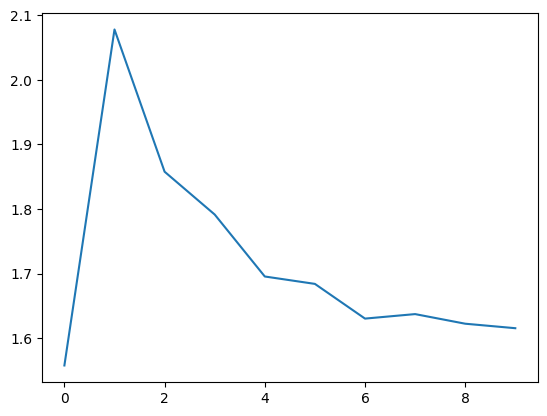

In [58]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline

plt.figure()
plt.plot(all_losses)

Шаблон функции `generate_sample` также доступен ниже. Вы можете как дозаполнить его, так и написать свою собственную функцию с нуля. Не забывайте, что все примеры в обучающей выборке начинались с токена `<sos>`.

In [59]:
def generate_sample(char_rnn, seed_phrase=None, max_length=200, temperature=1.0, device=device):
    '''
    The function generates text given a phrase of length at least SEQ_LENGTH.
    :param seed_phrase: prefix characters. The RNN is asked to continue the phrase
    :param max_length: maximum output length, including seed_phrase
    :param temperature: coefficient for sampling.  higher temperature produces more chaotic outputs,
                         smaller temperature converges to the single most likely output
    '''

    if seed_phrase is not None:
        x_sequence = [token_to_idx['<sos>']] + [token_to_idx[token] for token in seed_phrase]
    else: 
        x_sequence = [token_to_idx['<sos>']]

    x_sequence = torch.tensor([x_sequence], dtype=torch.int64).to(device)

    # подаем начальную фразу, если таковая имеется
    hidden = char_rnn.init_hidden().to(device)
    for i in range(len(seed_phrase) if seed_phrase is not None else 0):
        output, hidden = char_rnn(x_sequence[:, i], hidden)

   # начинаем генерировать
    for i in range(len(seed_phrase) if seed_phrase is not None else 0, max_length):
        output, hidden = char_rnn(x_sequence[:, -1], hidden)
        
        # выборка из модели в виде мультиномиального распределения
        output_dist = output.data.view(-1).div(temperature).exp()
        top_i = torch.multinomial(output_dist, 1)[0]

        # Добавляем предсказанный символ в строку и используем как следующий входной символ
        predicted_char = idx_to_token[top_i.item()]
        x_sequence = torch.cat((x_sequence, torch.tensor([[top_i]], dtype=torch.int64).to(device)), dim=1)

        if predicted_char == '<eos>':
            break

    return ''.join([idx_to_token[ix] for ix in x_sequence.cpu().data.numpy()[0]])

Пример текста сгенерированного обученной моделью доступен ниже. Не страшно, что в тексте много несуществующих слов. Используемая модель очень проста: это простая классическая RNN.

In [60]:
print(generate_sample(model, ' мой дядя самых честных правил', max_length=500, temperature=0.8))

<sos> мой дядя самых честных правилась
к ней не семья,
веселой предразнилась в соседи милал весны:
в ее нас други шамолюбила.



xli

в вери розвать она струстный руком
и нас полкало с боих,
надмет, в молодой,
она прифодных умом?». к забал,
и осщегой мудный пламенный мой чувства теперы,
и волны,
и сень,
одна, милаем любовь реветит и самом:
ее ничего…
к оставно и печали бледный,
гте был постеденной доповым старина,
и под бегой несевее постеле.
я мысла, на сее вмертительным возоким сладоскнут;
на… ни с


### Сдача задания
Сгенерируйте десять последовательностей длиной 500, используя строку ' мой дядя самых честных правил'. Температуру для генерации выберите самостоятельно на основании визуального качества генериуремого текста. Не забудьте удалить все технические токены в случае их наличия.

Сгенерированную последовательность сохрание в переменную `generated_phrase` и сдайте сгенерированный ниже файл в контест.

In [61]:
seed_phrase = ' мой дядя самых честных правил'

In [62]:
generated_phrases = [
    generate_sample(
        model,
        ' мой дядя самых честных правил',
        max_length=500,
        temperature=1.
    ).replace('<sos>', '')
    for _ in range(10)
]

generated_phrases

[' мой дядя самых честных правился,\nкак собою роскательный звон был про-возром увидает;\nчто он с своей бало счастел;\nтем ей забыв на сведа, ленских;\nк нем своем, укрывать помоди моложада,\nповернул, кого, и, дывал\nна чей беса гранителью,\nприди сокрожно ее страгам\nдомашний мерит\nи силых ком;\nзашего, своей,\nкогда б одно напосчел буду соэдой\nсосед тоская смустный обеда;\nи ных нас жизни благород8ать леда,\nно может:\nи что оa идета давно,\nв эти мои капиналах и в новая,\nпурким кобоком,\nгоразный с плеча в ',
 ' мой дядя самых честных правил\nуж небрагший… я тань его жевалось),\nчто по намголь о разливой запледнем как собратком\nрассьсе койски и тригала его тоскую:\nя валось… прыдалась врагом\nуж онегин, угряно\nу на послушки и кереда.\nдавно, а поли,\nда всё раз его так и верною совсекучный мерку,\nлюбви умчала, приборят,\nкой-ях друг, ножки чета\nв старил собой,\nурдечи моех.\n\n\n\nxii\n\nмей супругом содавется втё друг по ней верно,\nи нам рало,\nи жар нежду в улыбкой ерков

In [ ]:
# do not change the code in the block below
# __________start of block__________

import json
if 'generated_phrases' not in locals():
    raise ValueError("Please, save generated phrases to `generated_phrases` variable")

for phrase in generated_phrases:

    if not isinstance(phrase, str):
        raise ValueError("The generated phrase should be a string")

    if len(phrase) != 500:
        raise ValueError("The `generated_phrase` length should be equal to 500")

    assert all([x in set(tokens) for x in set(list(phrase))]), 'Unknown tokens detected, check your submission!'
    

submission_dict = {
    'token_to_idx': token_to_idx,
    'generated_phrases': generated_phrases
}

with open('submission_dict.json', 'w') as iofile:
    json.dump(submission_dict, iofile)
print('File saved to `submission_dict.json`')
# __________end of block__________

На этом задание завершено. Поздравляем!